In [1]:
## read the med slake responses 

import os
root_response_dir = '/staging/users/tpadhi1/Multimodal-Uncertainty-Quantification/runs_slake/llava_med_slake/explanations'
 
response_files = os.listdir(root_response_dir)

# load the first response file
import pickle
response_file = response_files[0]
response_path = os.path.join(root_response_dir, response_file)
with open(response_path, 'rb') as f:
    response = pickle.load(f)
    
print(response.keys())

dict_keys(['img_names', 'locations', 'answers', 'modalities', 'base_types', 'answer_types', 'questions', 'qids', 'content_types', 'triples', 'img_ids', 'q_langs', 'promptified_questions', 'image_paths', 'response_0', 'response_1', 'response_2', 'response_3', 'response_4', 'response_5', 'response_6', 'response_7', 'response_8', 'response_9', 'response_10', 'response_11', 'response_12', 'response_13', 'response_14', 'response_15', 'response_16', 'response_17', 'response_18', 'response_19'])


In [2]:
response['response_0'].keys()

dict_keys(['prompt', 'generated_token_ids', 'decoded_outputs', 'transition_scores'])

In [2]:
## lets see grounding with llama 3.2 V
gr_root_dir = '/staging/users/tpadhi1/Multimodal-Uncertainty-Quantification/runs_slake/llava_med_slake/grounding_with_llama32'
gr_files = os.listdir(gr_root_dir)

# load the first response file
gr_file = gr_files[0]
gr_path = os.path.join(gr_root_dir, gr_file)
with open(gr_path, 'rb') as f:
    gr = pickle.load(f)

In [3]:
gr.keys()

dict_keys(['img_names', 'locations', 'answers', 'modalities', 'base_types', 'answer_types', 'questions', 'qids', 'content_types', 'triples', 'img_ids', 'q_langs', 'promptified_questions', 'image_paths', 'response_0', 'response_1', 'response_2', 'response_3', 'response_4', 'response_5', 'response_6', 'response_7', 'response_8', 'response_9', 'response_10', 'response_11', 'response_12', 'response_13', 'response_14', 'response_15', 'response_16', 'response_17', 'response_18', 'response_19'])

In [4]:
gr['response_0'].keys()

dict_keys(['prompt', 'generated_token_ids', 'decoded_outputs', 'transition_scores', 'llama_32_response'])

In [1]:
import os
import pickle
import pandas as pd
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from tqdm import tqdm
import numpy as np

# Load models
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load DeBERTa for entailment
tokenizer = AutoTokenizer.from_pretrained("microsoft/deberta-large-mnli")
deberta_model = AutoModelForSequenceClassification.from_pretrained("microsoft/deberta-large-mnli").to(device)

# Load embedding model for consistency
st_model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

def get_accuracy(full_answers, question, responses, tokenizer, model, device):
    """Calculate accuracy using DeBERTa entailment"""
    correct = 0
    for response in responses:
        premise = f'{response.strip()}'
        hypothesis = f'{full_answers.strip()}'
        
        inputs = tokenizer.encode_plus(
            premise, 
            hypothesis, 
            return_tensors='pt', 
            truncation=True,
            max_length=512
        )
        inputs = {k: v.to(device) for k, v in inputs.items()}
        
        with torch.no_grad():
            logits = model(**inputs).logits
            pred = torch.argmax(logits, dim=1).item()
            if pred == 2:  # Entailment label
                correct += 1
    return correct / len(responses) if responses else 0


/home/tpadhi1/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/tpadhi1/miniconda3/envs/llava2/lib/python3.10/site-packages/transformers/utils/generic.py:484: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/home/tpadhi1/miniconda3/envs/llava2/lib/python3.10/site-packages/transformers/utils/hub.py:128: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(
/home/tpadhi1/miniconda3/envs/llava2/lib/python3.10/site-packages/transformers/utils/generic.py:341: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` ins

In [13]:
# Process all questions
data = []
for idx in tqdm(range(len(gr_files)), desc="Processing questions"):
    # read the first response file
    with open(os.path.join(gr_root_dir, gr_files[idx]), 'rb') as f:
        gr = pickle.load(f)
        
    # qid = gr['qids'][idx]
    # question = gr['questions'][idx]
    # answer = gr['answers'][idx]
    qid = gr['qids'][0]
    question = gr['questions'][0]
    answer = gr['answers'][0]
    
    # Collect responses and scores
    responses = [gr[f'response_{k}']['decoded_outputs'].strip() for k in range(20)]
    ground_responses = [gr[f'response_{k}']['llama_32_response'] for k in range(20)]
    yes_count = sum(1 for score in ground_responses if 'yes' in score.lower())
    grounding_score = yes_count / len(ground_responses)
    # print(grounding_score)
    
    # print(ground_scores)
    # 
    # Calculate metrics
    embeddings = st_model.encode(responses)
    sim_matrix = cosine_similarity(embeddings)
    np.fill_diagonal(sim_matrix, 0)
    consistency = sim_matrix.sum() / (sim_matrix.size - len(responses))  # Exclude diagonal
    
    accuracy = get_accuracy(
        full_answers=answer,
        question=question,
        responses=responses,
        tokenizer=tokenizer,
        model=deberta_model,
        device=device
    )
    
    data.append({
        'question_id': qid,
        'question': question,
        'answer': answer,
        'model_responses': responses,
        'self_consistency_score': consistency,
        'grounding_score': grounding_score,
        'accuracy': accuracy
    })
    #print all the above information
    print(f"Question ID: {qid}")
    print(f"Question: {question}")
    print(f"Answer: {answer}")
    print(f"Responses: {responses}")
    print(f"Consistency: {consistency:.2f}")
    print(f"Grounding: {grounding_score:.2f}")
    print(f"Accuracy: {accuracy:.2f}")
    
    # break

# Create DataFrame

df = pd.DataFrame(data)[[
    'question_id', 'question', 'answer', 'model_responses',
    'self_consistency_score', 'grounding_score', 'accuracy'
]]

# Add summary statistics
print(f"\nFinal DataFrame Shape: {df.shape}")
print(f"Average Accuracy: {df.accuracy.mean():.2f}")
print(f"Average Consistency: {df.self_consistency_score.mean():.2f}")
print(f"Average Grounding: {df.grounding_score.mean():.2f}")

# Show sample output
df.head()

Processing questions:   0%|          | 1/1640 [01:35<43:31:48, 95.61s/it]

Question ID: 2466
Question: What modality is shown in this image?
Answer: X-Ray
Responses: ['The image is a chest X-ray that shows a large mass in the abdomen. The mass appears to be extending into the right hemithorax, which is the right side of the chest cavity.', 'The image is a chest X-ray, which is a common diagnostic imaging technique used to visualize the structures within the chest, including the lungs, heart, and bones of the chest and spine.', 'The image is a chest X-ray, which is a common diagnostic imaging technique used to visualize the structures within the chest, including the lungs, heart, and bones of the chest and spine. In this case, the chest X-ray shows the lung and spinal cord.', "The image is a chest X-ray, which is a common diagnostic imaging technique used to visualize the structures within the chest, including the lungs, heart, and bones of the chest and spine. In this case, the chest X-ray was taken to assess the patient's condition after the removal of a med

Processing questions:   0%|          | 2/1640 [03:15<44:34:19, 97.96s/it]

Question ID: 1615
Question: What is the organ on the top of the body in this image?
Answer: Liver
Responses: ['The image is an axial section of an abdominal MRI. It is a cross-sectional view of the abdomen, which is the area between the chest and the pelvis. The main organs visible in this image are the spinal cord and the lung.', 'The image is a contrast-enhanced axial MRI of the abdomen. The main organ in the image is the Lung and Spinal Cord. However, without more specific information, it is difficult to determine the exact focus or any abnormalities present in the image.', 'The main organ in the image is the lung, which is part of the respiratory system. The lung is responsible for gas exchange and plays a crucial role in the process of respiration, where it takes in oxygen and releases carbon dioxide.', 'The image is a CT scan of the abdomen, and it shows a mass in the right lung and spinal cord.', 'The main organ in the image is the Lung and Spinal Cord. The image is an axial vie

Processing questions:   0%|          | 3/1640 [05:12<48:29:29, 106.64s/it]

Question ID: 314
Question: What is the largest organ in the picture?
Answer: Lung
Responses: ['The image is an MRI of the abdomen, which is a region of the body that includes various organs, such as the stomach, liver, intestines, and kidneys. The main organ in the image is the Lung and Spinal Cord. The largest organ in the picture is the Lung.', 'The image is a chest X-ray, which is a type of radiographic imaging that provides a view of the structures within the chest, including the lungs, heart, and bones of the chest and spine. In this case, the main organs visible in the image are the Lung and Spinal Cord.', 'The image is a chest X-ray.', 'The image is a chest X-ray, which is a common diagnostic imaging technique used to visualize the structures within the chest, including the lungs, heart, and bones of the chest and spine.', 'The image is a chest X-ray, which is a common imaging technique used to visualize the structures within the chest, including the lungs, heart, and bones of t

Processing questions:   0%|          | 3/1640 [05:59<54:26:45, 119.73s/it]


KeyboardInterrupt: 

In [14]:
# ok awesome now, we have the dataframe with all the information we need for all the responses
# path = '/staging/users/tpadhi1/Multimodal-Uncertainty-Quantification/final_df.csv'
path = '/staging/users/tpadhi1/Multimodal-Uncertainty-Quantification/final_df2.csv'
import pandas as pd
# read the dataframe
df = pd.read_csv(path)

In [15]:
df.head()

,question_id,question,answer,model_responses,image_id,image_path,self_consistency_score,grounding_score,accuracy
0,0,What modality is used to take this image?,MRI,"['The image is a T1-weighted MRI, which is a t...",1,/mnt/my_ebs_volume/home/ubuntu/Multimodal-Unce...,0.700985,0.00,0.50
1,10,What is the largest organ in the picture?,Liver,['The image is a coronal view of an abdomen MR...,100,/mnt/my_ebs_volume/home/ubuntu/Multimodal-Unce...,0.715044,0.25,0.15
2,1000,What organ is the black hole in the upper righ...,Stomach,['The black hole in the upper right corner of ...,226,/mnt/my_ebs_volume/home/ubuntu/Multimodal-Unce...,0.738243,0.05,0.25
3,1001,What is the shape of the kidney in the picture?,Irregular,"['The image is an abdominal MRI, which shows t...",226,/mnt/my_ebs_volume/home/ubuntu/Multimodal-Unce...,0.759484,0.05,0.00
4,1002,What modality is used to take this image?,CT,"['The image is an abdominal MRI, which is a ma...",227,/mnt/my_ebs_volume/home/ubuntu/Multimodal-Unce...,0.761038,0.20,0.35


Text(0.5, 0, 'Accuracy')

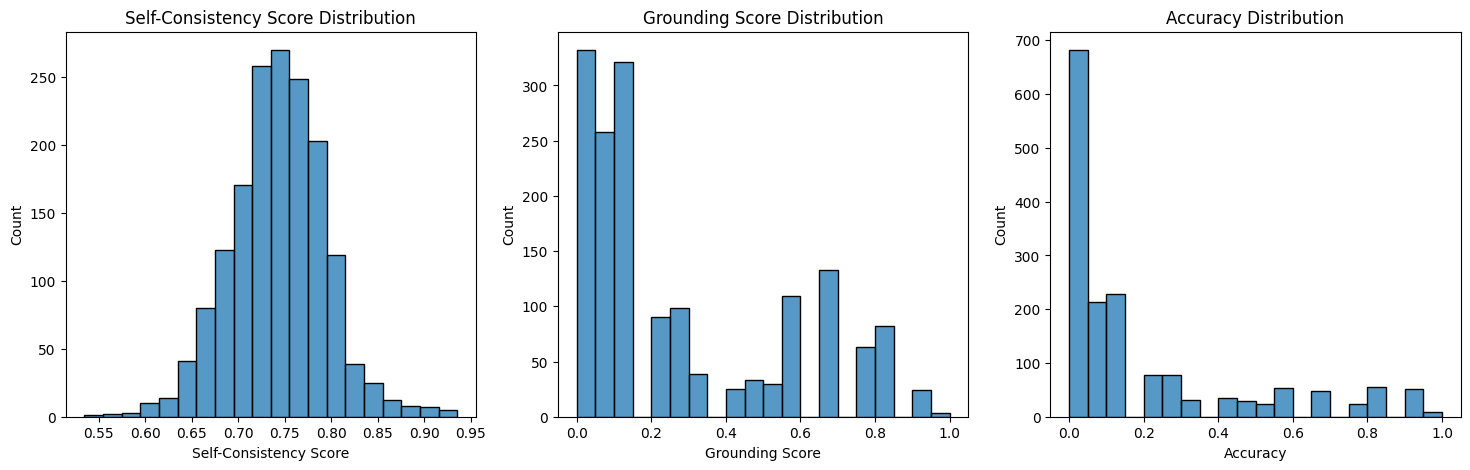

In [16]:
# lets plot the distribution of the self_consistency_score, grounding_score and accuracy
import matplotlib.pyplot as plt
import seaborn as sns

# Plot distribution of scores
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(df.self_consistency_score, bins=20, ax=axes[0])
axes[0].set_title('Self-Consistency Score Distribution')
axes[0].set_xlabel('Self-Consistency Score')

sns.histplot(df.grounding_score, bins=20, ax=axes[1])
axes[1].set_title('Grounding Score Distribution')
axes[1].set_xlabel('Grounding Score')

sns.histplot(df.accuracy, bins=20, ax=axes[2])
axes[2].set_title('Accuracy Distribution')
axes[2].set_xlabel('Accuracy')


In [17]:
# ok so now I want to get those responses - get those rows from the pandas dataframe which have low grounding and low accuracy but high self_consistency_score
low_grounding = df[df.grounding_score < 0.2]
low_accuracy = low_grounding[low_grounding.accuracy < 0.2]
high_consistency = low_accuracy[low_accuracy.self_consistency_score > 0.8]

# how many rows are there in each of these dataframes
print(low_grounding.shape, low_accuracy.shape, high_consistency.shape)

(911, 9) (687, 9) (66, 9)


In [18]:
high_consistency.head()

,question_id,question,answer,model_responses,image_id,image_path,self_consistency_score,grounding_score,accuracy
32,1080,What is the organ on the top of the body in th...,Liver,['The image is a contrast-enhanced computed to...,233,/mnt/my_ebs_volume/home/ubuntu/Multimodal-Unce...,0.803908,0.00,0.15
58,1133,What is the largest organ in the picture?,Lung,['The image is an axial computed tomography (C...,240,/mnt/my_ebs_volume/home/ubuntu/Multimodal-Unce...,0.808822,0.10,0.05
73,1179,What is the scanning plane of this image?,Transverse Plane,"['The image is a coronal MRI of the abdomen, w...",243,/mnt/my_ebs_volume/home/ubuntu/Multimodal-Unce...,0.800345,0.05,0.10
80,1194,What modality is used to take this image?,CT,['The image is a coronal view of an MRI scan o...,246,/mnt/my_ebs_volume/home/ubuntu/Multimodal-Unce...,0.801359,0.00,0.00
146,1357,What is the rightmost organ in this image?,Large Bowel,['The image is a contrast-enhanced computed to...,260,/mnt/my_ebs_volume/home/ubuntu/Multimodal-Unce...,0.811138,0.00,0.00


In [19]:
#save the high_consistency dataframe
high_consistency.to_csv('/staging/users/tpadhi1/Multimodal-Uncertainty-Quantification/high_consistency_low_acc_low_gr2.csv', index=False)

In [23]:
high_consistency['image_path'].iloc[0]

'/mnt/my_ebs_volume/home/ubuntu/Multimodal-Uncertainty-Quantification/dataset/SLAKE/Slake1.0/imgs/xmlab233/source.jpg'

(-0.5, 511.5, 511.5, -0.5)

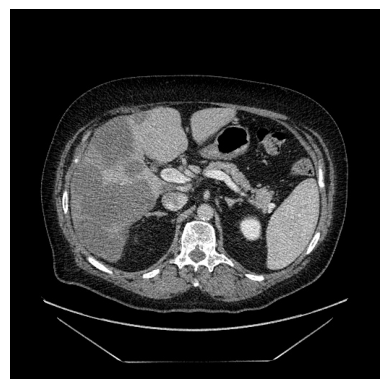

In [27]:
# can you plot the above image
import matplotlib.pyplot as plt
# import cv2
import numpy as np
from PIL import Image

image_path = high_consistency['image_path'].iloc[0].replace('/mnt/my_ebs_volume/home/ubuntu/Multimodal-Uncertainty-Quantification/dataset/SLAKE/Slake1.0/', '/staging/users/tpadhi1/Multimodal-Uncertainty-Quantification/datasets_/Slake1.0/')
image = Image.open(image_path)
plt.imshow(np.array(image))
plt.axis('off') 

In [1]:
# ok so now I want to get those responses - get those rows from the pandas dataframe which have high grounding and high accuracy but high self_consistency_score
import pandas as pd
df = pd.read_csv('/staging/users/tpadhi1/Multimodal-Uncertainty-Quantification/final_df2.csv')
low_grounding = df[df.grounding_score > 0.8]
low_accuracy = low_grounding[low_grounding.accuracy > 0.8]
high_consistency = low_accuracy[low_accuracy.self_consistency_score > 0.8]

In [2]:
high_consistency.head()

,question_id,question,answer,model_responses,image_id,image_path,self_consistency_score,grounding_score,accuracy
529,2289,What modality is used to take this image?,X-Ray,"['The image is a chest X-ray, which is a diagn...",339,/mnt/my_ebs_volume/home/ubuntu/Multimodal-Unce...,0.831361,1.00,0.85
610,2508,What type of medical image is this?,X-Ray,['The image is a chest X-ray (CXR) that shows ...,363,/mnt/my_ebs_volume/home/ubuntu/Multimodal-Unce...,0.818989,0.90,0.85
647,263,What modality is used to take this image?,X-Ray,"['The image is a chest X-ray, which is a commo...",143,/mnt/my_ebs_volume/home/ubuntu/Multimodal-Unce...,0.848731,0.85,0.90
1013,366,What modality is used to take this image?,X-Ray,"['The image is a chest X-ray, which is a commo...",158,/mnt/my_ebs_volume/home/ubuntu/Multimodal-Unce...,0.852878,0.95,0.85
1276,451,What modality is used to take this image?,X-Ray,"[""The image is a chest x-ray, which is a commo...",172,/mnt/my_ebs_volume/home/ubuntu/Multimodal-Unce...,0.812379,0.95,0.85


In [8]:
# ok now I just need 2 columns from each category 

# ok so now I want to get those responses - get those rows from the pandas dataframe which have low grounding and low accuracy but high self_consistency_score
low_grounding = df[df.grounding_score < 0.2]
low_accuracy = low_grounding[low_grounding.accuracy < 0.2]
high_consistency_low_gr = low_accuracy[low_accuracy.self_consistency_score > 0.8]


high_grounding = df[df.grounding_score > 0.6]
high_accuracy = high_grounding[high_grounding.accuracy > 0.6]
high_consistency_high_gr = high_accuracy[high_accuracy.self_consistency_score > 0.6]




In [9]:
high_consistency_high_gr.head()

,question_id,question,answer,model_responses,image_id,image_path,self_consistency_score,grounding_score,accuracy
275,165,What modality is used to take this image?,X-Ray,['The image is a chest X-ray that shows the pr...,123,/mnt/my_ebs_volume/home/ubuntu/Multimodal-Unce...,0.756681,0.75,0.80
312,173,What modality is used to take this image?,X-Ray,"['The image is a chest X-ray, which is a type ...",125,/mnt/my_ebs_volume/home/ubuntu/Multimodal-Unce...,0.761088,0.70,0.75
344,1797,What organ system is primarily present in this...,Chest,"['The image is a chest X-ray, which is a type ...",295,/mnt/my_ebs_volume/home/ubuntu/Multimodal-Unce...,0.728949,0.70,0.90
349,1813,What is the main organ in the image?,Lung,['The main organ in the image is the Lung and ...,296,/mnt/my_ebs_volume/home/ubuntu/Multimodal-Unce...,0.935688,0.65,0.95
354,1822,What modality is shown in this image?,X-Ray,['The image is a chest X-ray (CXR) of a patien...,297,/mnt/my_ebs_volume/home/ubuntu/Multimodal-Unce...,0.807509,0.75,0.90


In [10]:
high_consistency_high_gr['question'].value_counts()

question
What modality is used to take this image?                56
What organ system is primarily present in this image?    17
What organ system is pictured?                           14
What is the main organ in the image?                     12
What modality is shown in this image?                     9
What is the organ system visualized?                      7
What imaging modality was used?                           3
What type of medical image is this?                       2
Name: count, dtype: int64

In [14]:
# get all the rows where the question is 'What is the main organ in the image?'

test = high_consistency_high_gr[high_consistency_high_gr['question'] == 'What is the main organ in the image?'].head()

In [15]:
test.to_csv('/staging/users/tpadhi1/Multimodal-Uncertainty-Quantification/demo/demo_highgr.csv', index=False)

In [5]:
combined_df = pd.concat([high_consistency_high_gr.head(20), high_consistency_low_gr.head(20)], ignore_index=True)
combined_df.head()

,question_id,question,answer,model_responses,image_id,image_path,self_consistency_score,grounding_score,accuracy
0,2289,What modality is used to take this image?,X-Ray,"['The image is a chest X-ray, which is a diagn...",339,/mnt/my_ebs_volume/home/ubuntu/Multimodal-Unce...,0.831361,1.00,0.85
1,2508,What type of medical image is this?,X-Ray,['The image is a chest X-ray (CXR) that shows ...,363,/mnt/my_ebs_volume/home/ubuntu/Multimodal-Unce...,0.818989,0.90,0.85
2,263,What modality is used to take this image?,X-Ray,"['The image is a chest X-ray, which is a commo...",143,/mnt/my_ebs_volume/home/ubuntu/Multimodal-Unce...,0.848731,0.85,0.90
3,366,What modality is used to take this image?,X-Ray,"['The image is a chest X-ray, which is a commo...",158,/mnt/my_ebs_volume/home/ubuntu/Multimodal-Unce...,0.852878,0.95,0.85
4,451,What modality is used to take this image?,X-Ray,"[""The image is a chest x-ray, which is a commo...",172,/mnt/my_ebs_volume/home/ubuntu/Multimodal-Unce...,0.812379,0.95,0.85


In [6]:
combined_df['question'].value_counts()

question
What modality is used to take this image?                      9
What is the largest organ in the picture?                      3
What is the rightmost organ in this image?                     2
What is the scanning plane of this image?                      2
What type of medical image is this?                            1
What is the organ on the top of the body in this image?        1
What diseases are included in the picture?                     1
What is the mr weighting in this image?                        1
What color are the eyes in the picture?                        1
What organ is the on the right of the image?                   1
What color does the spinal cord show in the picture?           1
What is the function of the organ on the top of this image?    1
What organ system is pictured?                                 1
What organ is the white part on the top of the image?          1
Name: count, dtype: int64

In [7]:
high_consistency_high_gr['question'].value_counts()

question
What modality is used to take this image?    5
What type of medical image is this?          1
Name: count, dtype: int64

In [ ]:
# What is the largest organ in the picture?                      3
# What is the rightmost organ in this image?                     2
# What organ is the white part on the top of the image?          1



In [6]:
# lets save this dataframe
combined_df.to_csv('/staging/users/tpadhi1/Multimodal-Uncertainty-Quantification/demo/combined_df.csv', index=False)

In [11]:
import ast
responses = ast.literal_eval(combined_df['model_responses'].iloc[0])


In [2]:
path = '/staging/users/tpadhi1/Multimodal-Uncertainty-Quantification/high_consistency_low_acc_low_gr2.csv'
import pandas as pd
# read the dataframe
df = pd.read_csv(path)

df.head()

,question_id,question,answer,model_responses,image_id,image_path,self_consistency_score,grounding_score,accuracy
0,1080,What is the organ on the top of the body in th...,Liver,['The image is a contrast-enhanced computed to...,233,/mnt/my_ebs_volume/home/ubuntu/Multimodal-Unce...,0.803908,0.00,0.15
1,1133,What is the largest organ in the picture?,Lung,['The image is an axial computed tomography (C...,240,/mnt/my_ebs_volume/home/ubuntu/Multimodal-Unce...,0.808822,0.10,0.05
2,1179,What is the scanning plane of this image?,Transverse Plane,"['The image is a coronal MRI of the abdomen, w...",243,/mnt/my_ebs_volume/home/ubuntu/Multimodal-Unce...,0.800345,0.05,0.10
3,1194,What modality is used to take this image?,CT,['The image is a coronal view of an MRI scan o...,246,/mnt/my_ebs_volume/home/ubuntu/Multimodal-Unce...,0.801359,0.00,0.00
4,1357,What is the rightmost organ in this image?,Large Bowel,['The image is a contrast-enhanced computed to...,260,/mnt/my_ebs_volume/home/ubuntu/Multimodal-Unce...,0.811138,0.00,0.00


In [12]:
# df['question_id']
# i want to to get the row where the question_id is 3246
df[df['question_id'] == 3246] # low accuracy, low grounding, high consistency


,question_id,question,answer,model_responses,image_id,image_path,self_consistency_score,grounding_score,accuracy
30,3246,What is the organ system visualized?,Head,['The image is a coronal view of an MRI of the...,435,/mnt/my_ebs_volume/home/ubuntu/Multimodal-Unce...,0.825021,0.0,0.0


In [13]:
df2_path = '/staging/users/tpadhi1/Multimodal-Uncertainty-Quantification/demo/demo_highgr.csv'
df2 = pd.read_csv(df2_path)
df2[df2['question_id'] == 2164] # high accuracy, high grounding, high consistency



,question_id,question,answer,model_responses,image_id,image_path,self_consistency_score,grounding_score,accuracy
4,2164,What is the main organ in the image?,Lung,['The main organ in the image is the lung and ...,328,/mnt/my_ebs_volume/home/ubuntu/Multimodal-Unce...,0.784574,0.7,0.7


In [14]:
# I want to add both of these and make a new dataframe
combined_df_demo_feb4 = pd.concat([df[df['question_id'] == 3246], df2[df2['question_id'] == 2164]], ignore_index=True)
combined_df_demo_feb4.to_csv('/staging/users/tpadhi1/Multimodal-Uncertainty-Quantification/demo/combined_df_demo_feb4.csv', index=False)

In [1]:
path = '/staging/users/tpadhi1/Multimodal-Uncertainty-Quantification/demo/combined_df_demo_feb4.csv'
import pandas as pd
# read the dataframe
df = pd.read_csv(path)

df.head()

,question_id,question,answer,model_responses,image_id,image_path,self_consistency_score,grounding_score,accuracy
0,3246,What is the organ system visualized?,Head,['The image is a coronal view of an MRI of the...,435,/staging/users/tpadhi1/Multimodal-Uncertainty-...,0.825021,0.0,0.0
1,2164,What is the main organ in the image?,Lung,['The main organ in the image is the lung and ...,328,/staging/users/tpadhi1/Multimodal-Uncertainty-...,0.784574,0.7,0.7


In [3]:
df['overall_confidence_score'] = 0.5*df['self_consistency_score'] + 0.5*df['grounding_score'] 
df.head()

,question_id,question,answer,model_responses,image_id,image_path,self_consistency_score,grounding_score,accuracy,overall_uncertainty_score,overall_confidence_score
0,3246,What is the organ system visualized?,Head,['The image is a coronal view of an MRI of the...,435,/staging/users/tpadhi1/Multimodal-Uncertainty-...,0.825021,0.0,0.0,0.412510,0.412510
1,2164,What is the main organ in the image?,Lung,['The main organ in the image is the lung and ...,328,/staging/users/tpadhi1/Multimodal-Uncertainty-...,0.784574,0.7,0.7,0.742287,0.742287


In [6]:
combined_df = pd.read_csv('/staging/users/tpadhi1/Multimodal-Uncertainty-Quantification/demo/combined_df_demo_feb4.csv')
combined_df_demo_feb4 = pd.concat([combined_df[combined_df['question_id'] == 2164], combined_df[combined_df['question_id'] == 3246]], ignore_index=True)



combined_df_demo_feb4.to_csv('/staging/users/tpadhi1/Multimodal-Uncertainty-Quantification/demo/combined_df_demo_feb4_new.csv', index=False)